# TFLite로 경량화


In [1]:
import tensorflow as tf

In [3]:
import os
import keras

In [5]:
load_path = r"C:\Users\User\Documents\GitHub\mlops\7_MLOps\cifar10_tuned_model\1"
best_model = keras.layers.TFSMLayer(load_path, call_endpoint='serving_default')


In [7]:
model_path = './cifar10_tuned_model/1'
model = keras.layers.TFSMLayer(model_path, call_endpoint='serving_default')

### SavedModel의 시그니처 확인

In [11]:
# SavedModel의 시그니처 확인 (Check SavedModel signatures)
print("\nModel signatures:", list(tf.saved_model.load(model_path).signatures.keys()))


Model signatures: ['serve', 'serving_default']


### SavedModel 모델 구조 확인

In [15]:
# SavedModel의 시그니처 확인 (Check SavedModel signatures)
saved_model = tf.saved_model.load(model_path)
infer = saved_model.signatures['serving_default']

print("\nModel Input Spec:")
for key, value in infer.structured_input_signature[1].items():
    print(f"Input {key}: shape = {value.shape}, dtype = {value.dtype}")

print("\nModel Output Spec:")
for key, value in infer.structured_outputs.items():
    print(f"Output {key}: shape = {value.shape}, dtype = {value.dtype}")


Model Input Spec:
Input keras_tensor_22: shape = (None, 32, 32, 3), dtype = <dtype: 'float32'>

Model Output Spec:
Output output_0: shape = (None, 10), dtype = <dtype: 'float32'>


### TF Lite 모델로 변환 & TF Lite 모델 저장

In [16]:
# TFLite 변환 (Convert to TFLite)
converter = tf.lite.TFLiteConverter.from_saved_model(model_path)
tflite_model = converter.convert()

# TFLite 모델 저장 (Save TFLite model)
with open('cifar10_model.tflite', 'wb') as f:
    f.write(tflite_model)

### TF Lite 모델 테스트


입력 텐서 정보 (Input tensor details):

이름 (Name): serving_default_keras_tensor_22:0
형태 (Shape): [ 1 32 32  3]
타입 (Type): <class 'numpy.float32'>

출력 텐서 정보 (Output tensor details):

이름 (Name): StatefulPartitionedCall_1:0
형태 (Shape): [ 1 10]
타입 (Type): <class 'numpy.float32'>


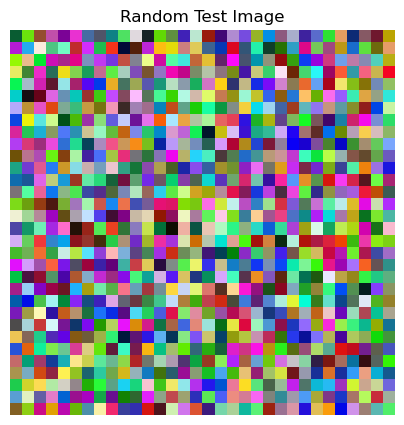


예측된 클래스 (Predicted class): automobile

각 클래스별 확률 (Probabilities for each class):
airplane: 0.0027
automobile: 0.8481
bird: 0.0001
cat: 0.0001
deer: 0.0216
dog: 0.0000
frog: 0.1140
horse: 0.0000
ship: 0.0000
truck: 0.0133


In [19]:
import numpy as np
import matplotlib.pyplot as plt


# TFLite 인터프리터 생성 (Create TFLite interpreter)
interpreter = tf.lite.Interpreter(model_path='cifar10_model.tflite')
interpreter.allocate_tensors()

# 입력과 출력 상세정보 가져오기 (Get input and output details)
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\n입력 텐서 정보 (Input tensor details):")
for detail in input_details:
    print(f"\n이름 (Name): {detail['name']}")
    print(f"형태 (Shape): {detail['shape']}")
    print(f"타입 (Type): {detail['dtype']}")

print("\n출력 텐서 정보 (Output tensor details):")
for detail in output_details:
    print(f"\n이름 (Name): {detail['name']}")
    print(f"형태 (Shape): {detail['shape']}")
    print(f"타입 (Type): {detail['dtype']}")

# 테스트 이미지 생성 (Create test image)
test_image = np.random.rand(1, 32, 32, 3).astype(np.float32)

# 이미지 시각화 (Visualize image)
plt.figure(figsize=(5, 5))
plt.imshow(test_image[0])  # [0]으로 배치 차원 제거 / Remove batch dimension with [0]
plt.title("Random Test Image")
plt.axis('off')
plt.show()

# 입력 텐서 설정 (Set input tensor)
interpreter.set_tensor(input_details[0]['index'], test_image)

# 추론 실행 (Run inference)
interpreter.invoke()

# 출력 가져오기 (Get output)
output_data = interpreter.get_tensor(output_details[0]['index'])

# CIFAR-10 클래스 이름 (CIFAR-10 class names)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 결과 출력 (Print results)
predicted_class = np.argmax(output_data[0])
print(f"\n예측된 클래스 (Predicted class): {class_names[predicted_class]}")
print("\n각 클래스별 확률 (Probabilities for each class):")
for i, (name, prob) in enumerate(zip(class_names, output_data[0])):
    print(f"{name}: {prob:.4f}")